In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load Data
test_pd = pd.read_csv("data/test.csv")
train_pd = pd.read_csv("data/train.csv")

In [3]:
#Separate target & combine Data
survived= train_pd["Survived"]
train_pd.drop(columns="Survived",inplace=True)
combined_pd = pd.concat([train_pd,test_pd]).reset_index(drop=True)

train_ids = train_pd["PassengerId"]
test_ids = test_pd["PassengerId"]

unique_classes = combined_pd["Pclass"].unique()

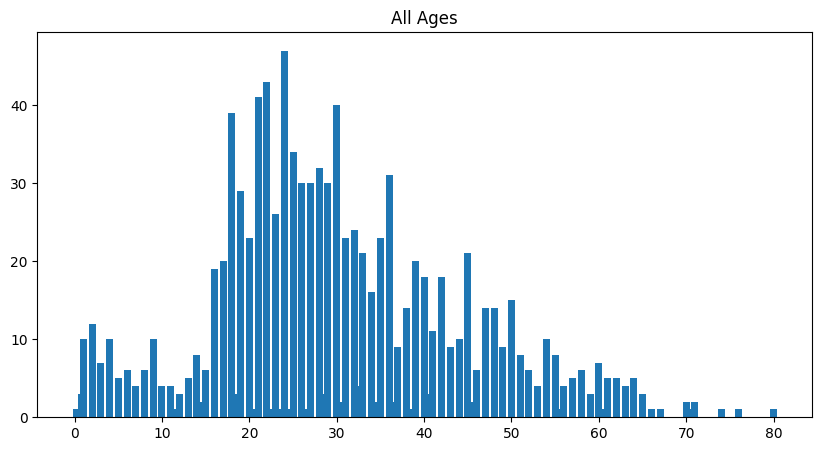

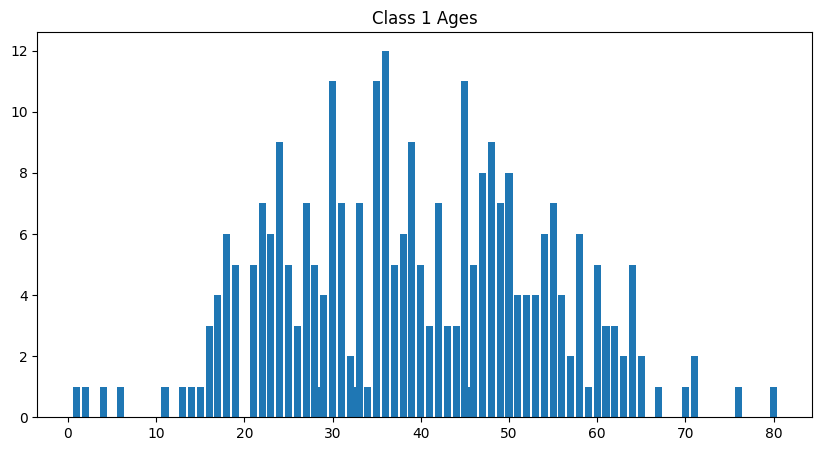

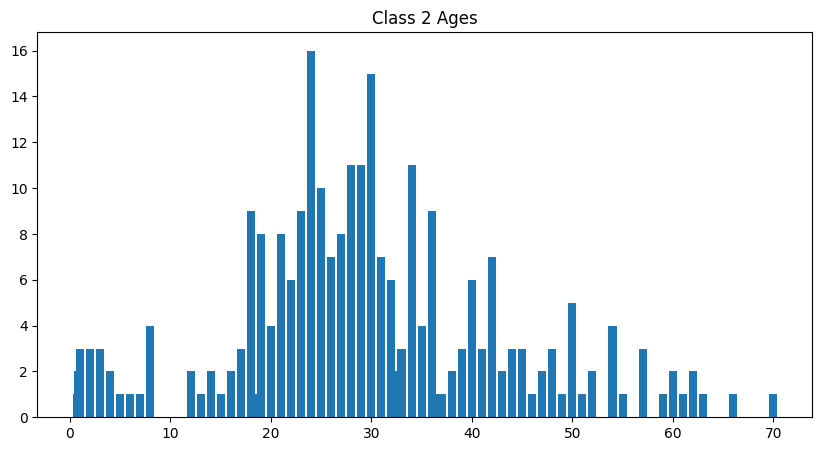

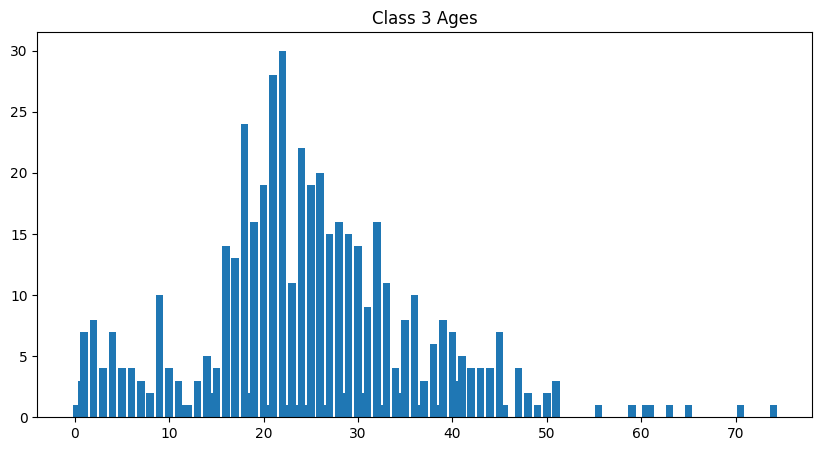

In [4]:
#Visualize age distribution
def plot_age_distribution(df):
    y = df['Age'].value_counts()
    plt.figure(figsize=(10,5))
    plt.bar(y.index.values, y)
    plt.title("All Ages")
    plt.show()

    for i in range(1, len(unique_classes)+ 1):
        y = df[df["Pclass"] == i]["Age"].value_counts()
        plt.figure(figsize=(10,5))
        plt.bar(y.index.values, y)
        plt.title(f"Class {i} Ages")
        plt.show()

plot_age_distribution(combined_pd)

In [6]:
# Fill missing ages
def fill_age_by_pclass(df):
    median_ages = df.groupby("Pclass")["Age"].median()
    for pclass, median in median_ages.items():
        idx = np.where((df["Pclass"] == pclass) & (df["Age"].isnull()))[0]
        df.loc[idx, "Age"] = median
    return df

combined_pd = fill_age_by_pclass(combined_pd)
combined_pd.isnull().sum()

PassengerId       0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [ ]:
print()